# Commodity Price Forecasting — Data Collection
### Project by Rayan Rawat

This notebook covers:
- Downloading historical price data for BRENT, WTI, Gasoil, RBOB and Heating Oil
- Initial data inspection and cleaning
- Saving clean data for EDA and modelling

**Data Source:** Yahoo Finance via `yfinance`  
**Time Period:** January 2010 — Present  
**Frequency:** Daily OHLCV data


## Import Libraries
We import all necessary libraries for data collection, manipulation and visualization.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("All libraries imported successfully!")

## Step 1 — Define Commodities
We focus on 5 energy commodities traded on NYMEX and ICE. 
Note: Gasoil (GAS=F) was delisted on Yahoo Finance — replaced with Natural Gas (NG=F) 
which offers strong seasonal patterns useful for forecasting.

In [ ]:

tickers = {
    'BRENT': 'BZ=F',
    'WTI':   'CL=F',
    'NATURAL_GAS': 'NG=F',
    'RBOB':  'RB=F',
    'HEATING_OIL': 'HO=F'
}

print("Tickers defined:")
for name, symbol in tickers.items():
    print(f"  {name}: {symbol}")

## Step 2 — Download Historical Price Data
We pull 15 years of daily OHLCV data (2010–present) from Yahoo Finance.
15 years covers multiple oil market cycles:
- 2014 oil price crash
- 2020 COVID crash
- 2022 Russia-Ukraine price spike

In [ ]:
raw_data = {}

for name, symbol in tickers.items():
    print(f"Downloading {name}...")
    df = yf.download(symbol, start='2010-01-01', progress=False)
    raw_data[name] = df
    print(f"  Got {len(df)} rows | From {df.index[0].date()} to {df.index[-1].date()}")

print("\nAll commodities downloaded successfully!")

## Step 3 — Sanity Check
Before touching the data we verify:
- Shape: expected ~3800 rows per commodity
- Date range: should start 2010-01-04
- Columns: Open, High, Low, Close, Volume
- Missing values: any gaps we need to handle

In [ ]:
for name in raw_data:
    df = raw_data[name]
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Shape     : {df.shape[0]} rows x {df.shape[1]} columns")
    print(f"  Date range: {df.index[0].date()} to {df.index[-1].date()}")
    print(f"  Columns   : {list(df.columns)}")
    print(f"  Missing   : {df.isnull().sum().sum()} missing values")

## Observations
- All 5 commodities downloaded successfully with ~4000+ rows each
- Date range confirmed: 2010-01-04 to 2026-05-01
- 0 missing values across all commodities — data is clean
- Column names are MultiIndex (e.g. ('Close', 'BZ=F')) — will fix in next step

## Step 4 — Clean Column Names
yfinance returns messy column names like ('Close', 'BZ=F').
We simplify them to just 'Close', 'High', 'Low', 'Open', 'Volume'.

In [ ]:
column_mapping = {
    'C': 'Close',
    'H': 'High', 
    'L': 'Low',
    'O': 'Open',
    'V': 'Volume'
}

for name in raw_data:
    df = raw_data[name]
    # First keep only first level if MultiIndex
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = [col[0] for col in df.columns]
    # Then rename to full names
    df.rename(columns=column_mapping, inplace=True)
    raw_data[name] = df

# Verify
print("Column names after cleaning:")
for name in raw_data:
    print(f"  {name}: {list(raw_data[name].columns)}")

## Step 5 — Save Data to CSV
We save each commodity's data as a separate CSV file.
This means we never need to re-download from Yahoo Finance again.
All future notebooks will load data directly from these CSV files.

In [ ]:
# Create a folder called 'data' to store all CSV files
os.makedirs('data', exist_ok=True)

# Save each commodity as a separate CSV
for name in raw_data:
    filepath = f'data/{name}.csv'
    raw_data[name].to_csv(filepath)
    print(f"Saved {name} → {filepath}")

print("\nAll files saved successfully!")

## Step 6 — Visual Inspection
We plot closing prices for all 5 commodities to visually identify:
- Long term price trends
- Major market events (2014 crash, 2020 COVID, 2022 Russia-Ukraine)
- Seasonal patterns
- Differences in price levels and volatility across commodities

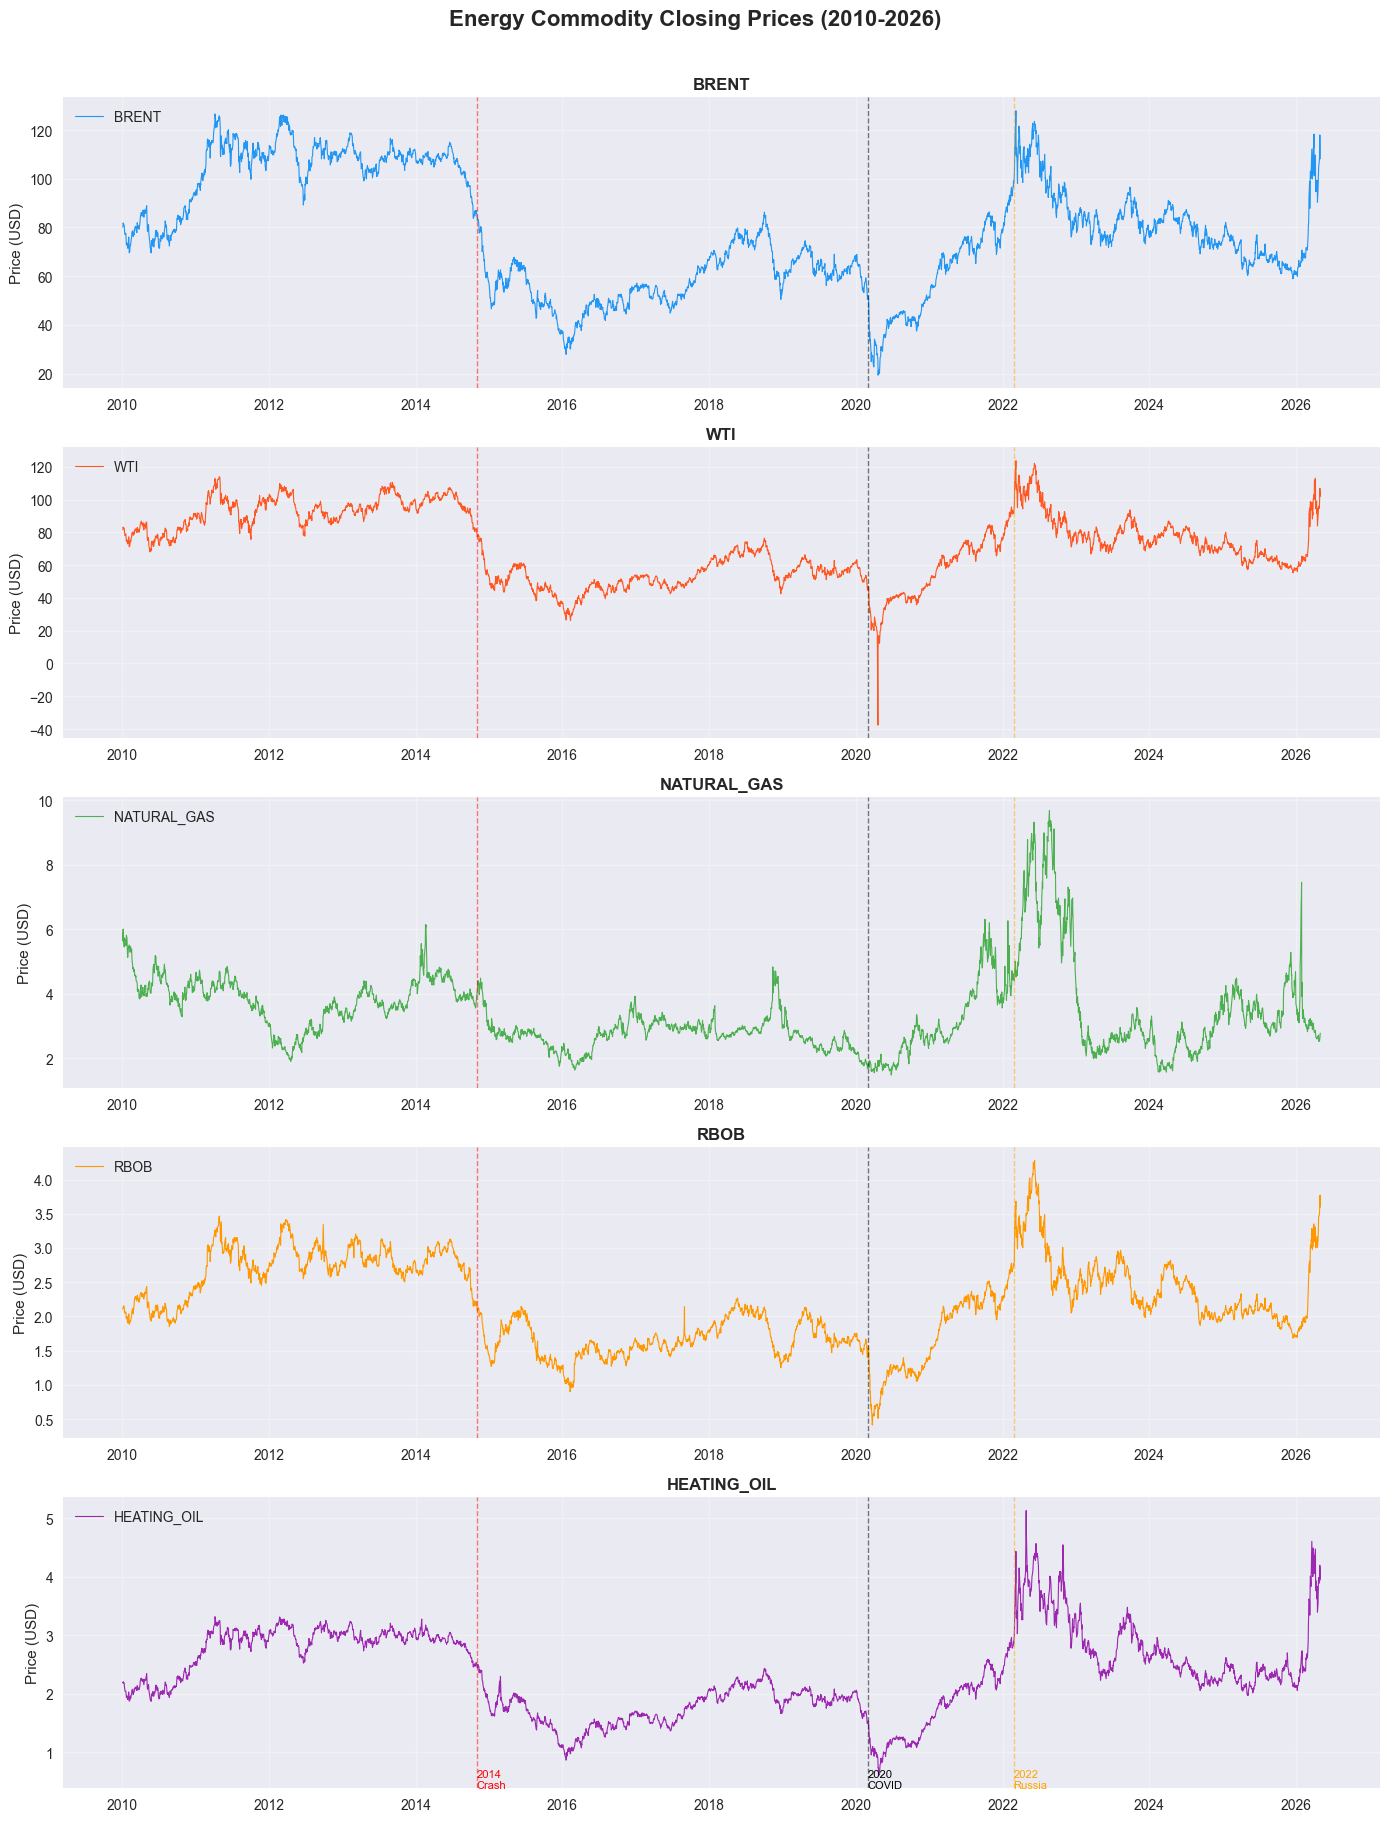

Chart saved to data/price_history.png


In [21]:
# ============================================================
# STEP 7 — Plot closing prices for all commodities
# ============================================================

fig, axes = plt.subplots(5, 1, figsize=(14, 18))
fig.suptitle('Energy Commodity Closing Prices (2010-2026)', 
             fontsize=16, fontweight='bold', y=1.01)

colors = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

for idx, (name, color) in enumerate(zip(raw_data.keys(), colors)):
    ax = axes[idx]
    df = raw_data[name]
    
    ax.plot(df.index, df['Close'], color=color, linewidth=0.8, label=name)
    
    # Mark major market events
    ax.axvline(pd.Timestamp('2014-11-01'), color='red', 
               linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(pd.Timestamp('2020-03-01'), color='black', 
               linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(pd.Timestamp('2022-02-24'), color='orange', 
               linestyle='--', alpha=0.5, linewidth=1)
    
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper left')

# Add event labels on last plot
axes[-1].text(pd.Timestamp('2014-11-01'), axes[-1].get_ylim()[0], 
              '2014\nCrash', fontsize=8, color='red')
axes[-1].text(pd.Timestamp('2020-03-01'), axes[-1].get_ylim()[0], 
              '2020\nCOVID', fontsize=8, color='black')
axes[-1].text(pd.Timestamp('2022-02-24'), axes[-1].get_ylim()[0], 
              '2022\nRussia', fontsize=8, color='orange')

plt.tight_layout()
plt.savefig('data/price_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to data/price_history.png")
